### Organize data for segmentation and ensure GPU is available

In [17]:
# Configure parameters and path names for segmentation

experiment = 'SK_SFv7_December_2024'
segname = 'dapi'
data_folder = r'D:\241207_WTC11_SFv7'
save_dir = f'D:\\241207_WTC11_SFv7\\{experiment}\\{segname}'

from ioMicro import read_im
import numpy as np
import glob
import zarr
import os

In [18]:
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="1"

import torch
torch.cuda.is_available()

True

In [19]:
torch.cuda.get_device_name(0)

'NVIDIA RTX A6000'

In [21]:
#checks gpu and their properties
!nvidia-smi

Thu Jan  9 13:44:01 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 552.12                 Driver Version: 552.12         CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:21:00.0  On |                  N/A |
|  0%   44C    P8             11W /  170W |    1618MiB /  12288MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
# Identify and count files (fovs) to segment 

zarr_files = r'D:\241207_WTC11_SFv7\H9_MER\Conv_zscan1_*.zarr'
files = list(sorted(list(glob.glob(zarr_files))))
print(f"Found {len(files)} files to segment")

Found 184 files to segment


In [36]:
# Read image data from each fov using read_im function from ioMicro

im_path = r'D:\241207_WTC11_SFv7\H9_MER\*'
imgs = [read_im(im_path) for im_path in files]
# imgs_DAPI = [read_im(im_path) for im_path in files]

In [37]:
imgs[15].shape

(4, 40, 2800, 2800)

In [38]:
imgs[20]

dask.array<swapaxes, shape=(4, 40, 2800, 2800), dtype=uint16, chunksize=(1, 1, 2800, 2800), chunktype=numpy.ndarray>

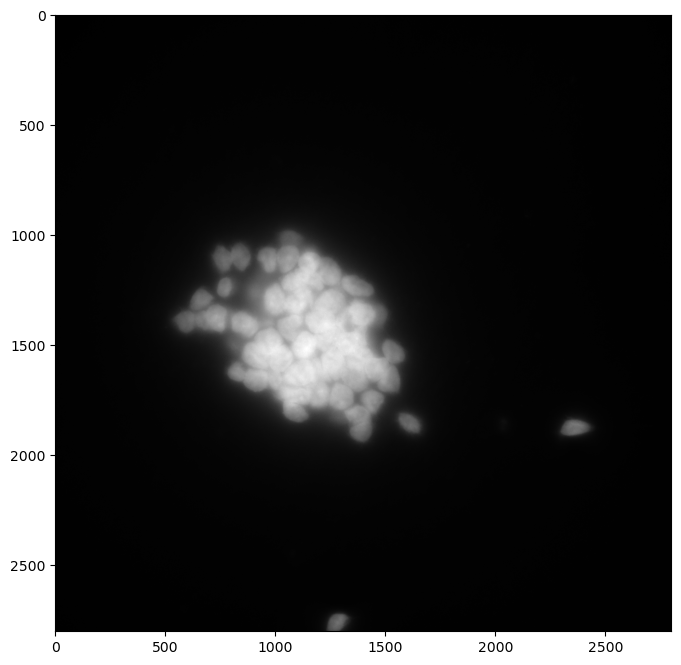

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

#imgs[x] gives fov; then [laser channel (4 total:0: 750, 1: cy5; 2:cy3, last is dapi), z slice, x, y] 
ax.imshow(imgs[22][3,15,:,:], cmap='gray', vmax=15000)
#for picking a slice, look for less blurry-the more clear, the better segmentation

#### Specify single polyA/dapi slice from each fov to use for segmentation 

In [40]:
#once you choose a slice, you make a new list of only this 2d view, so list of 2D from 3D; does this for each FOV
for i in range(184):
    imgs[i] = imgs[i][3,15,:,:]

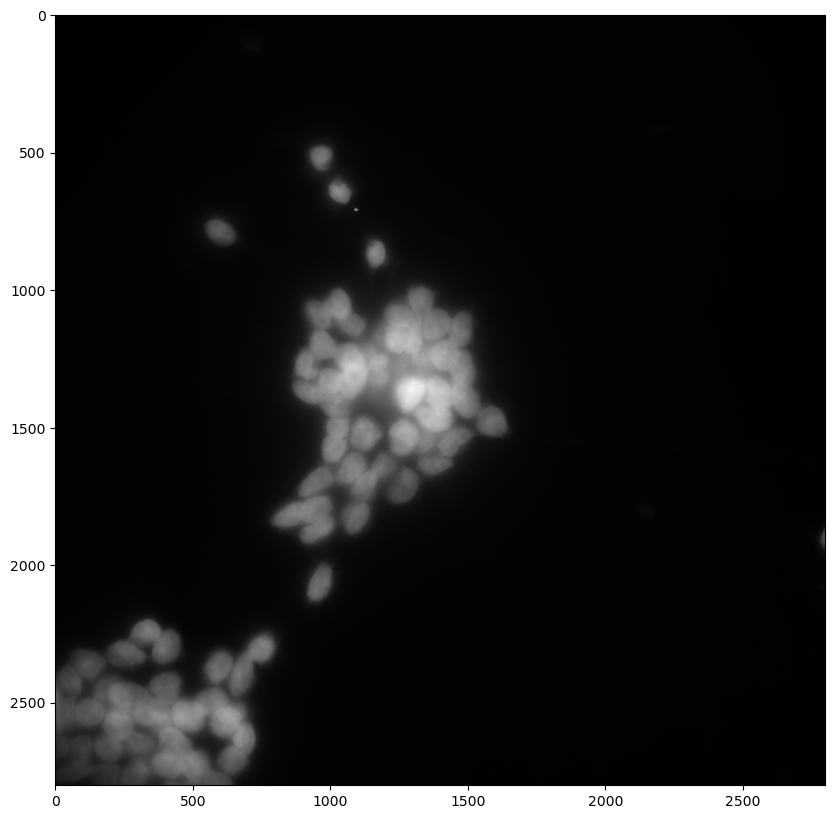

In [42]:
#now you've picked a plane and you look at all fovs in that plane
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,10))

ax.imshow(imgs[30], cmap='gray')

### Test cellpose on an image

In [43]:
imgs[16].shape

(2800, 2800)

In [47]:
from cellpose import models, io
from tqdm import tqdm #j a progress bar - look at first cell under run cellpose

model = models.CellposeModel(gpu=True, pretrained_model=r'C:\Users\zgibbs\cellpose\models\WTC11_dapi',
                            device=torch.device(0))
#this uses pre-trained function, test with j nuclei-- if pretrained model, ddiameter is None or 0; also channels is grayscale if [0,0]; if nuclei model, adjust diameter

masks, flows, styles = model.eval(imgs[126], channels=[0,0], do_3D=False, diameter=None,
                                 channel_axis=None, z_axis=0)

C:\Users\zgibbs\anaconda3\envs\cellpose3\lib\site-packages\cellpose\resnet_torch.py:271: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filename, map_

In [48]:
import napari

viewer = napari.Viewer()

In [49]:
viewer.add_image(imgs[121])

<Image layer 'Image' at 0x17717b4a080>

TypeError: Invalid shape (40, 2800, 2800) for image data

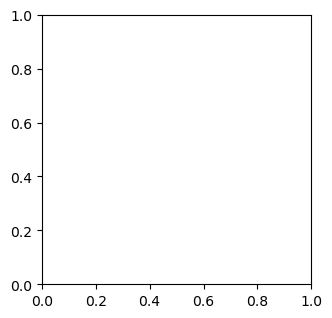

In [198]:
from cellpose import plot
import matplotlib.pyplot as plt

# img1 = imgs[126] # convert image from dask array to numpy array

maski = masks
flowi = flows[0]
channels= [0,0]

fig = plt.figure(figsize=(16,7))
plot.show_segmentation(fig, imgs[126], maski, flowi, channels=channels)
plt.tight_layout()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/ZaneTrit_3_3_2023/figures/cyto2_model_segmentation_plot.png', dpi=300)
plt.show()

### Train a new cellpose model

In [19]:
?train.train_seg

Signature:
train.train_seg(
    net,
    train_data=None,
    train_labels=None,
    train_files=None,
    train_labels_files=None,
    train_probs=None,
    test_data=None,
    test_labels=None,
    test_files=None,
    test_labels_files=None,
    test_probs=None,
    load_files=True,
    batch_size=8,
    learning_rate=0.005,
    n_epochs=2000,
    weight_decay=1e-05,
    momentum=0.9,
    SGD=False,
    channels=None,
    channel_axis=None,
    rgb=False,
    normalize=True,
    compute_flows=False,
    save_path=None,
    save_every=100,
    save_each=False,
    nimg_per_epoch=None,
    nimg_test_per_epoch=None,
    rescale=True,
    scale_range=None,
    bsize=224,
    min_train_masks=5,
    model_name=None,
)
Docstring:
Train the network with images for segmentation.

Args:
    net (object): The network model to train.
    train_data (List[np.ndarray], optional): List of arrays (2D or 3D) - images for training. Defaults to None.
    train_labels (List[np.ndarray], optional): List

In [99]:
# convert imgs from dask array to numpy array for cellpose training
imgs_ = np.asarray(imgs, dtype=np.uint16)

In [105]:
masks[19]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint16)

In [116]:
from cellpose import io, models, train
io.logger_setup()

# output = io.load_train_test_data(train_dir=imgs[0:50], test_dir=None, image_filter="_img",
#                                 mask_filter="_masks", look_one_level_down=False)

# images, labels, image_names, test_images, test_labels, image_names_test = output

# e.g. retrain a Cellpose model
model = models.CellposeModel(gpu=True, model_type="nuclei",
                            device=torch.device(0))

# use list of numpy arrays as image data, and the masks outputs from segmentation as labels
model_path, train_losses, test_losses = train.train_seg(model.net,
                            train_data=imgs_[:20], train_labels=masks[:20],
                            channels=[0,0], normalize=True, train_files=None,
                            train_labels_files=None, rescale=True,
                            test_data=imgs_[21:41], test_labels=masks[21:41],
                            weight_decay=1e-5, SGD=True, learning_rate=0.005,
                            n_epochs=1000, model_name="WTC11_dapi")

creating new log file
2024-12-27 14:40:23,666 [INFO] WRITING LOG OUTPUT TO C:\Users\zgibbs\.cellpose\run.log
2024-12-27 14:40:23,666 [INFO] 
cellpose version: 	3.1.0 
platform:       	win32 
python version: 	3.10.16 
torch version:  	2.5.1
2024-12-27 14:40:23,667 [INFO] >> nuclei << model set to be used
2024-12-27 14:40:23,746 [INFO] >>>> loading model C:\Users\zgibbs\.cellpose\models\nucleitorch_0
2024-12-27 14:40:23,838 [INFO] >>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
2024-12-27 14:40:23,840 [INFO] computing flows for labels


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:10<00:00,  1.94it/s]

2024-12-27 14:40:34,456 [INFO] computing flows for labels



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:11<00:00,  1.76it/s]

2024-12-27 14:40:46,144 [INFO] >>> computing diameters



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 51.02it/s]

2024-12-27 14:40:46,932 [INFO] >>> using channels [0, 0]
2024-12-27 14:40:46,933 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2024-12-27 14:40:53,326 [INFO] >>> n_epochs=1000, n_train=20, n_test=20
2024-12-27 14:40:53,327 [INFO] >>> SGD, learning_rate=0.00500, weight_decay=0.00001, momentum=0.900
2024-12-27 14:40:53,329 [INFO] >>> saving model to C:\Users\zgibbs\cellpose\models\WTC11_dapi
2024-12-27 14:40:56,578 [INFO] 0, train_loss=0.2631, test_loss=0.3072, LR=0.000000, time 3.25s
2024-12-27 14:41:06,462 [INFO] 5, train_loss=0.2388, test_loss=0.2814, LR=0.002778, time 13.13s
2024-12-27 14:41:16,581 [INFO] 10, train_loss=0.2399, test_loss=0.3227, LR=0.005000, time 23.25s
2024-12-27 14:41:34,949 [INFO] 20, train_loss=0.1796, test_loss=0.2798, LR=0.005000, time 41.62s
2024-12-27 14:41:53,321 [INFO] 30, train_loss=0.1897, test_loss=0.2709, LR=0.005000, time 59.99s
2024-12-27 14:42:11,865 [INFO] 40, train_loss=0.1910, test_loss=0.2720, LR=0.005000, time 78.54s
2024-12-27 14:42:30,308 [INFO] 50, train_loss=0.1685, test_loss=0.2634, LR=0.005000, time 96.98s
2024-12-27 14:42:48,917 [INFO] 60, train_loss=0.1725, test

2025-01-02 10:57:40,792 [INFO] >>>> loading model C:\Users\zgibbs\cellpose\models\WTC11_dapi
2025-01-02 10:57:40,882 [INFO] >>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
2025-01-02 10:57:40,882 [INFO] >>>> model diam_labels =  103.039 (mean diameter of training ROIs)


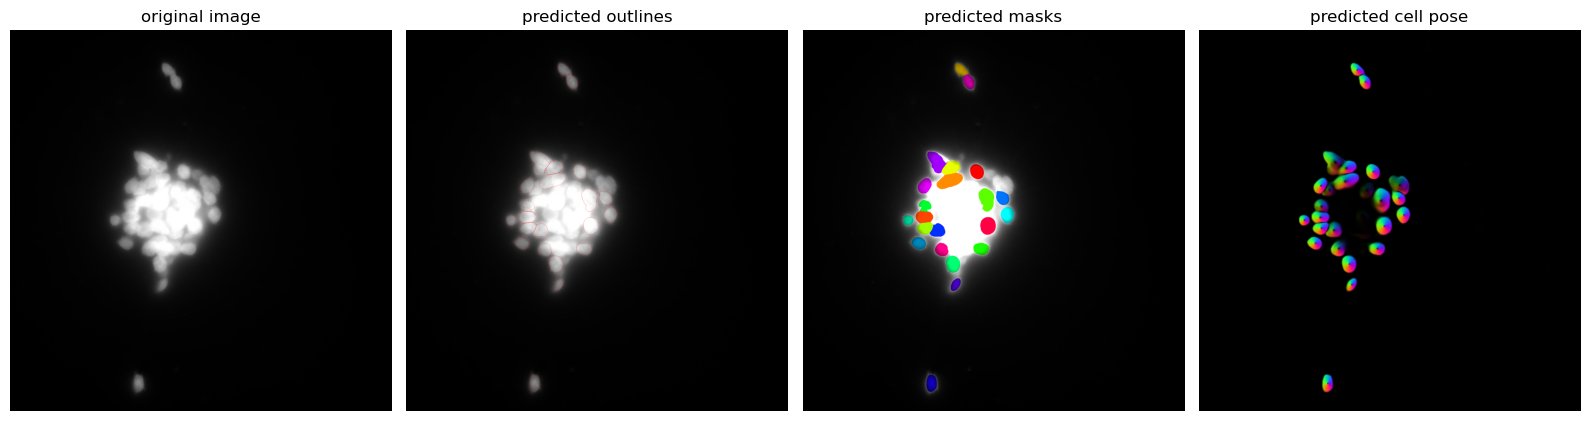

In [121]:
# Test the newly trained model on a single image

from cellpose import models, io, plot
from tqdm import tqdm
import matplotlib.pyplot as plt

model = models.CellposeModel(gpu=True, pretrained_model=r'C:\Users\zgibbs\cellpose\models\WTC11_dapi',
                            device=torch.device(0))

masks_, flows_, styles_ = model.eval(imgs_[176], channels=[0,0], diameter=None)

maski = masks_
flowi = flows_[0]

fig = plt.figure(figsize=(16,7))
plot.show_segmentation(fig, imgs_[176], maski, flowi)
plt.tight_layout()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/ZaneTrit_3_3_2023/figures/cyto2_model_segmentation_plot.png', dpi=300)
plt.show()

2025-01-02 11:05:20,236 [INFO] >> nuclei << model set to be used
2025-01-02 11:05:20,313 [INFO] >>>> loading model C:\Users\zgibbs\.cellpose\models\nucleitorch_0
2025-01-02 11:05:20,390 [INFO] >>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)


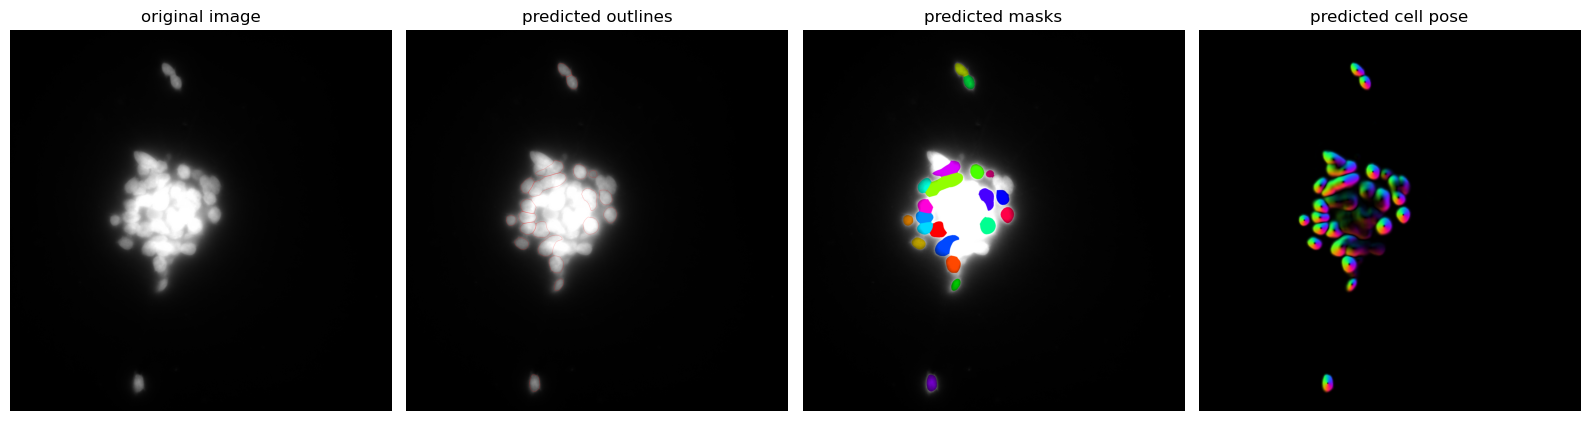

In [123]:
# Test the newly trained model on a single image

from cellpose import models, io, plot
from tqdm import tqdm
import matplotlib.pyplot as plt

model = models.CellposeModel(gpu=True, model_type='nuclei',
                            device=torch.device(0))

masks_, flows_, styles_ = model.eval(imgs_[176], channels=[0,0], diameter=100)

maski = masks_
flowi = flows_[0]

fig = plt.figure(figsize=(16,7))
plot.show_segmentation(fig, imgs_[176], maski, flowi)
plt.tight_layout()

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/ZaneTrit_3_3_2023/figures/cyto2_model_segmentation_plot.png', dpi=300)
plt.show()

## Run cellpose

In [13]:
# RUN CELLPOSE FOR ALL FOVS
from cellpose import models, io
from tqdm import tqdm

# DEFINE CELLPOSE MODEL
# model_type='cyto2' or pretrained_model='<path_to_model>'

# model = models.CellposeModel(gpu=True, pretrained_model=r'C:\Users\zgibbs\cellpose\HCT116_polyA_230320',
#                             device=torch.device(0))

model = models.CellposeModel(gpu=True, pretrained_model=r'C:\Users\zgibbs\cellpose\models\WTC11_dapi',
                            device=torch.device(0))

# Set the cell diameter manually (will determine automatically if 'None')
# Set the diameter to '0' if using a trained model
# HCT116 diameter = ~245

# masks, flows, styles = model.eval(imgs, channels=[0,0], diameter=0)

masks, flows, styles = [], [], []
for img in tqdm(imgs, desc='Segmented FOVs'):
    mask, flow, style = model.eval(img, channels=[0,0], diameter=0)
    masks.append(mask)
    flows.append(flow)
    styles.append(style)

C:\Users\zgibbs\anaconda3\envs\cellpose3\lib\site-packages\cellpose\resnet_torch.py:271: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filename, map_

#### Expand mask labels 

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import expand_labels

newmasks = []

for mask in masks:
    newmask = mask.copy()
    for cellid, size in zip(*np.unique(mask, return_counts=True)):
        if size < 2500:
            newmask[newmask==cellid] = 0
    newmask = expand_labels(newmask, 3)
    newmasks.append(newmask)

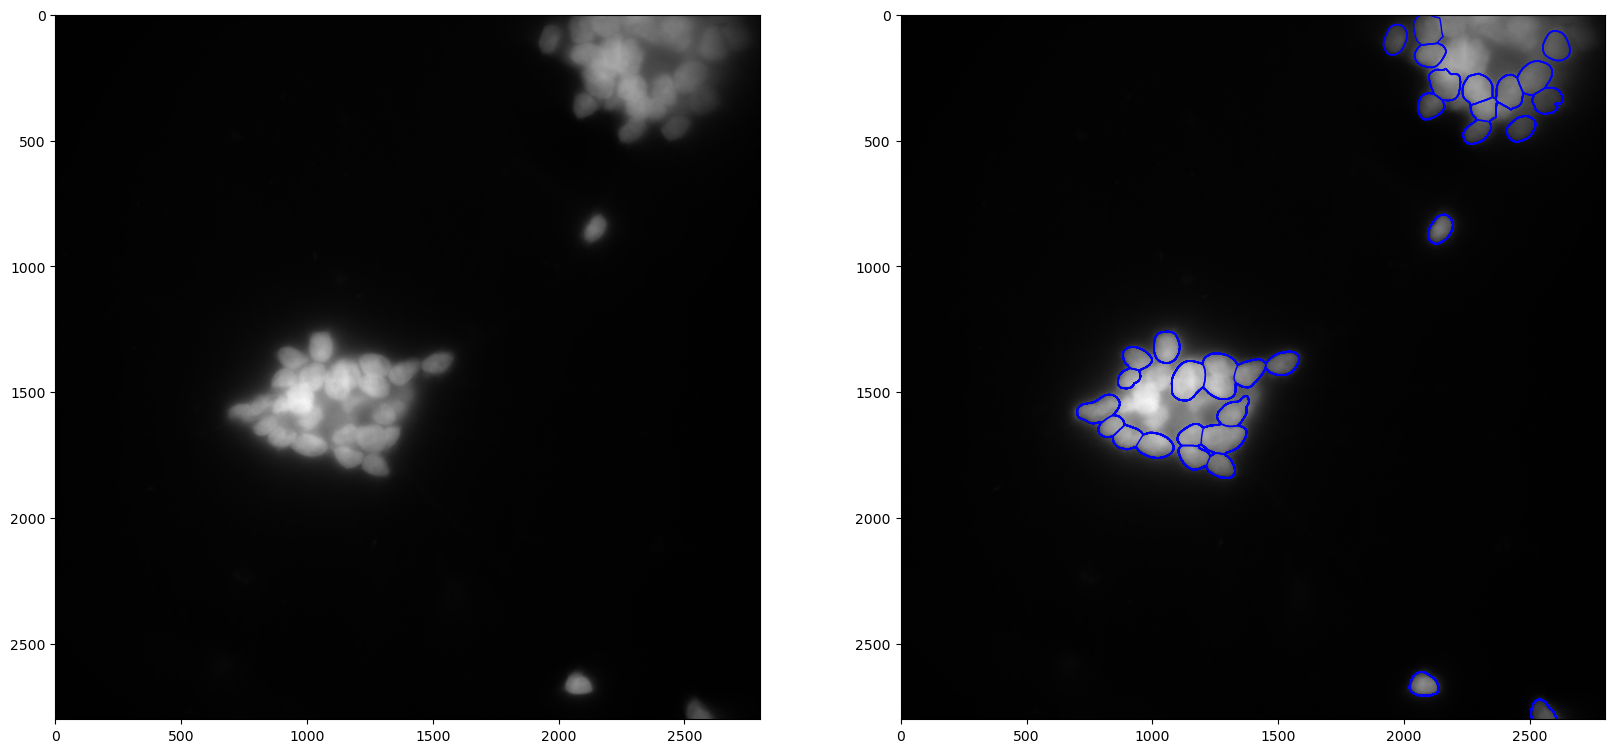

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(20,10))

fov = 70

ax[0].imshow(imgs[fov], cmap='gray')
ax[1].imshow(imgs[fov], cmap='gray')
ax[1].contour(newmasks[fov], [0.5+x for x in np.unique(newmasks[fov])], colors='b', linewidths=1)

In [16]:
os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

io.masks_flows_to_seg(imgs, newmasks, flows, file_names=savefiles, diams=0) # use 'diams=0' here for pre-trained model
io.save_to_png(imgs, newmasks, flows, file_names=savefiles)

### Save segmentation masks

In [24]:
# os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

In [25]:
savefiles

['/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__000.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__001.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__002.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__003.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__004.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__005.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__006.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__007.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Conv_zscan__008.zarr',
 '/projects/ps-renlab2/zgibbs/cellpose/10_12_2023__CRE-20_RNASEQ/polyA_slice20/Con

In [ ]:
os.makedirs(save_dir)
savefiles = [os.path.join(save_dir, os.path.basename(file)) for file in files]

io.masks_flows_to_seg(imgs, newmasks, flows, file_names=savefiles, diams=0) # use 'diams=0' here for pre-trained model
io.save_to_png(imgs, newmasks, flows, file_names=savefiles)

### Plot cell centers and/or spots with the segmentation masks